In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

aorta_path = '/data2/project/bin_jip/Biomarker/data/aorta/sample_aorta_data_filtered.h5ad'
asthma_path = '/data2/project/bin_jip/Biomarker/data/asthma/asthma_baseline_filtered.h5ad'
np_path = '/data2/project/bin_jip/Biomarker/data/asthma/NP_genes/NP_max.tsv'


/data2/project/bin_jip/miniconda3/envs/biomarker/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
asthma = sc.read_h5ad(asthma_path)

In [3]:
aorta = sc.read_h5ad(aorta_path)

/data2/project/bin_jip/miniconda3/envs/biomarker/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Number of overlapping genes: 1000


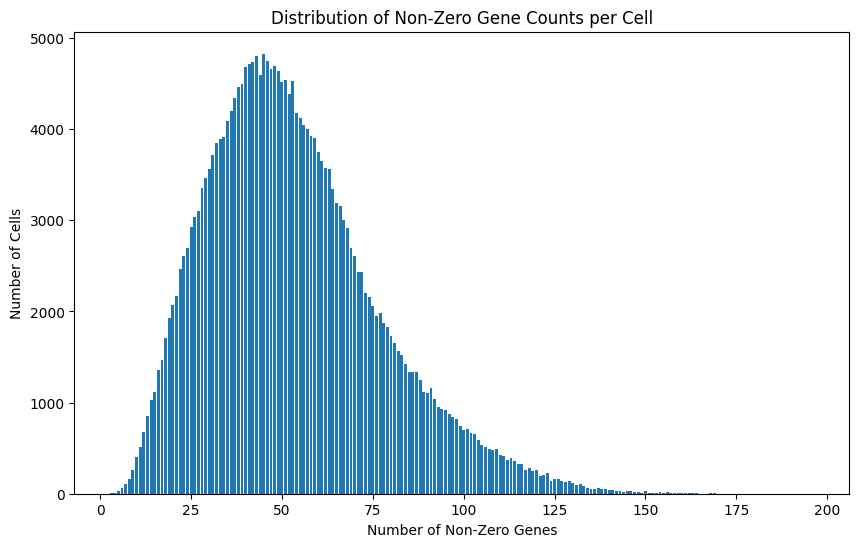

In [4]:
"""
asthma file에서 vars 중에서 /data2/project/bin_jip/Biomarker/data/asthma/NP_genes/NP_max.tsv 에서 
"전체가 아니라" 상위 2000 row의 'gene' column에 있는 것들만 먼저 list로 만들고 겹치는 것들만 봤을 때,
총 2000개의 유전자 중에서 몇 개가 존재하는가?
그 중에서 expression이 0이 아닌 유전자는 몇 개인가? 그 개수를 count해서 분포를 뽑아보자.
y축은 0이 아닌 gene의 개수, x축은 그 개수를 가진 cell을 많은 순서대로 정렬한 것
"""

np_genes_df = pd.read_csv(np_path, sep='\t')
np_genes = np_genes_df['gene'].tolist()[:1000]
asthma_vars = asthma.var_names.tolist()
overlap_genes = list(set(np_genes) & set(asthma_vars))
print(f"Number of overlapping genes: {len(overlap_genes)}")

asthma_np = asthma[:, overlap_genes]
non_zero_counts = np.sum(asthma_np.X.toarray() > 0, axis=1)
non_zero_counts_series = pd.Series(non_zero_counts).value_counts().sort_index()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(non_zero_counts_series.index, non_zero_counts_series.values)
plt.xlabel('Number of Non-Zero Genes')
plt.ylabel('Number of Cells')
plt.title('Distribution of Non-Zero Gene Counts per Cell')
plt.show()




Number of overlapping genes in aorta: 934


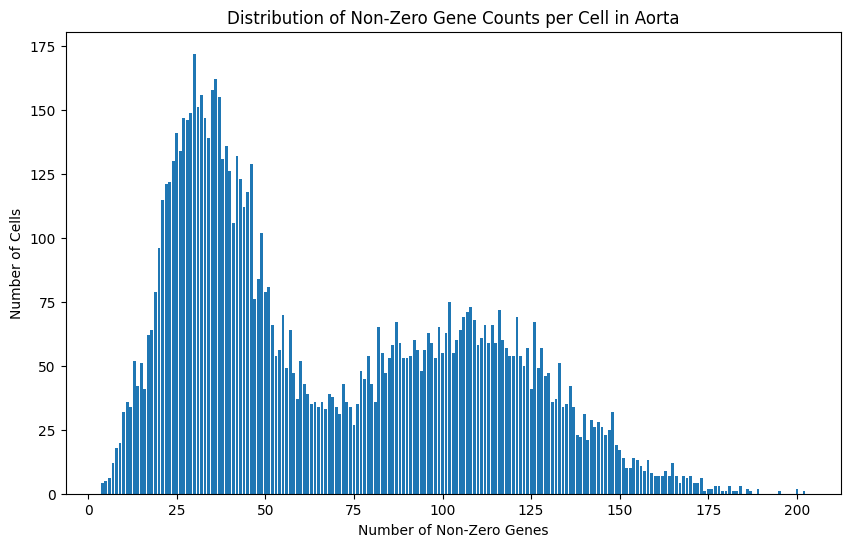

In [5]:
"aorta도 똑같이"
np_genes_df = pd.read_csv(np_path, sep='\t')
np_genes = np_genes_df['gene'].tolist()[:1000]
aorta_vars = aorta.var_names.tolist()
overlap_genes_aorta = list(set(np_genes) & set(aorta_vars))
print(f"Number of overlapping genes in aorta: {len(overlap_genes_aorta)}")
aorta_np = aorta[:, overlap_genes_aorta]
non_zero_counts_aorta = np.sum(aorta_np.X.toarray() > 0, axis=1)
non_zero_counts_series_aorta = pd.Series(non_zero_counts_aorta).value_counts().sort_index()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(non_zero_counts_series_aorta.index, non_zero_counts_series_aorta.values)
plt.xlabel('Number of Non-Zero Genes')
plt.ylabel('Number of Cells')
plt.title('Distribution of Non-Zero Gene Counts per Cell in Aorta')
plt.show()


In [25]:
"그 expression 값들의 최소 최대 "
"log normalized 되어서 모델에 들어갈 준비가 되어있는 상태인지 sanity check"

min_expression = asthma_np.X.min()
max_expression = asthma_np.X.max()
print(f"Minimum expression value: {min_expression}")
print(f"Maximum expression value: {max_expression}")

# log normalized 상태인지 확인 
if min_expression >= 0 and max_expression <= 10:
    print("The expression values appear to be log normalized.")
else:
    print("The expression values do not appear to be log normalized.")

"non zero들의 평균과 분산도 계산"
non_zero_values = asthma_np.X[asthma_np.X > 0]
mean_non_zero = np.mean(non_zero_values)
variance_non_zero = np.var(non_zero_values)
print(f"Mean of non-zero expression values: {mean_non_zero}")
print(f"Variance of non-zero expression values: {variance_non_zero}")


Minimum expression value: 0.0
Maximum expression value: 6.84164087336749
The expression values appear to be log normalized.
Mean of non-zero expression values: 1.5129833150909442
Variance of non-zero expression values: 0.3988680582828845
